# $\beta$-Regularity for $1$-Forms in 2D

### How degrading the smoothness of the velocity field affects computed spectra and pseudospectra

---

The convergence theory for these eigenvalue problems rests on regularity assumptions about
the velocity field $\beta$. This notebook measures what happens when those assumptions are
weakened: first for fields in $L^\infty\setminus W^{1,\infty}$ — bounded but not Lipschitz
— and then for fields in $L^p$ only, which fall outside the $L^\infty$ hypothesis that the
inf–sup conditions and the boundedness of the advective bilinear form are built on.

Every experiment is on $\Omega = (0,\pi)^2$, and every one is run in **three formulations**
that discretise the same continuous operator, so that consistency between them can be used
as a diagnostic where no analytic answer exists.

**Contents**

1. [The problem and the three formulations](#1)
2. [The velocity fields](#2)
3. [Fields in $L^\infty\setminus W^{1,\infty}$](#3)
4. [Fields in $L^p$](#4)
5. [Summary](#5)

The companion notebook `beta_regularity_topform.ipynb` runs the same programme for top
forms ($k=n=2$), where a deliberately spurious element is available as a further control.

<a id="0"></a>
## 0. Setup

Two modules carry everything that is not specific to this study:
`spectral_common.py` (meshes, the shift-and-invert solve, conditioning estimates, the
numerical-analysis utilities and the table formatter) and `pseudospectra_partial_schur.py`
(the $\varepsilon$-pseudospectrum engine). The formulations themselves are defined here,
because they are the subject.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

import spectral_common as sc
import pseudospectra_partial_schur as ps
from spectral_common import (crisscross_mesh, solve_pencil, border_gauge,
                             condition_estimates, rates, assign,
                             agreeing_digits, spread, L_DOMAIN, KAPPA_LOG)

# `from firedrake import *` exports a `logging` of its own, so the standard
# library one has to be re-imported under another name afterwards.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})
PS_RC = {
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
}


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

PETSc scalars: float64


<a id="1"></a>
## 1. The problem and the three formulations

We consider a $1$-form in 2D ($n = 2$, $k = 1$). Using the rotated proxy correspondences,
the half-Hodge $B$-formulation reads: find $\lambda\in\mathbb{C}$ and
$u \in H_0(\operatorname{curl};\Omega)$ with $u \neq 0$ such that, for some $p \in H^1_0(\Omega)$,

$$
\begin{cases}
\varepsilon\,(\nabla\times u,\ \nabla\times v) + (u\times\beta,\ \nabla\times v) - (\nabla p,\ v) = \lambda\,(u, v) & \forall v \in H_0(\operatorname{curl};\Omega),\\[2pt]
(u,\ \nabla q) = 0 & \forall q \in H^1_0(\Omega),
\end{cases}
$$

with $\varepsilon = R_m^{-1}$. In two dimensions $\nabla\times$ of a vector is the scalar
$\operatorname{rot} u = \partial_x u_2 - \partial_y u_1$, and $u\times\beta$ is the scalar
$u_1\beta_2 - u_2\beta_1$ — which is exactly the proxy of the contraction
$\iota^1_\beta u$. The multiplier $p$ enforces the constraint weakly; the boundary
condition is the perfectly-conducting one, $u\times n = 0$.

Two conforming choices of mixed space preserve the structure, and they are the only
difference between the two $B$ rows:

$$
B(\mathcal{N}^{\mathrm{I}}_r):\quad \mathcal{N}^{\mathrm{I}}_r \times \mathcal{P}_r ,
\qquad\qquad
B(\mathcal{N}^{\mathrm{II}}_r):\quad \mathcal{N}^{\mathrm{II}}_r \times \mathcal{P}_{r+1} ,
$$

Nédélec of the first (trimmed) and second (full) kind, the scalar partner one degree
higher in the second case so that $\nabla\mathcal{P}_{r+1}\subseteq\mathcal{N}^{\mathrm{II}}_r$
still holds.

The **potential formulation** writes $u = \nabla\times A$ for a scalar potential, which
satisfies the constraint identically. What is left undetermined is the additive constant,
fixed by a single real multiplier $t$: find $\lambda$ and $A$ with

$$
\begin{cases}
\varepsilon(\nabla A, \nabla z) + (\beta\cdot\nabla A,\ z) - (t, z) = \lambda(A, z) & \forall z \in H^1(\Omega),\\[2pt]
(A, s) = 0 & \forall s \in \mathbb{R},
\end{cases}
$$

discretised as $A(\mathcal{P}_r)$ with continuous Lagrange elements of degree $r$.

> **A note on the boundary condition.** No essential condition is imposed on $A$. The
> tangential condition $u\times n = 0$ of the $B$-formulations translates into the
> *natural* condition $\partial_n A = 0$, which is what makes the three formulations
> discretise the same operator — and the agreement in Section 3.1 is the evidence. Imposing
> $A\in H^1_0$ instead would give the Dirichlet spectrum and the three would not agree; the
> real multiplier $t$ would also be redundant, since the constant is not in $H^1_0$.

Because all three discretise the same continuous operator, their numerical stability and
robustness can be compared directly as the regularity of $\beta$ degrades.

In [2]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_1b_2 - a_2b_1$.

    Antisymmetric, so the ordering is load-bearing: the induction term needs
    $u\times\beta$, the proxy of the contraction $\iota^1_\beta u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, r):
    """The mixed (or scalar) space of one formulation at polynomial degree r."""
    if form == "A(P)":
        return FunctionSpace(mesh, "CG", r)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", r) * FunctionSpace(mesh, "CG", r)
    return FunctionSpace(mesh, "N2curl", r) * FunctionSpace(mesh, "CG", r + 1)


def build_pencil(form, mesh, r=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case."""
    if form == "A(P)":
        V = space(form, mesh, r)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K, M = assemble(a).petscmat, assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge (A, s) = 0 as a rank-one border.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_gauge(K, M, g)
        return A_b, M_b, V

    W = space(form, mesh, r)
    (u, q) = TrialFunctions(W)
    (v, s) = TestFunctions(W)
    a = eps * inner(curl(u), curl(v)) * dx
    if beta is not None:
        a += inner(cross2d(u, beta), curl(v)) * dx
    a += (-inner(grad(q), v) + inner(u, grad(s))) * dx
    # On an H(curl) space a DirichletBC constrains the TANGENTIAL trace, which is
    # the perfectly-conducting condition; p = 0 puts the multiplier in H^1_0.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the boundary
    # modes go to infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat, W)


FORMS = ["B(N1)", "B(N2)", "A(P)"]
TEX = {"B(N1)": r"$B(\mathcal{N}^{\mathrm{I}}_r)$",
       "B(N2)": r"$B(\mathcal{N}^{\mathrm{II}}_r)$",
       "A(P)":  r"$A(\mathcal{P}_r)$"}
TAG = {"B(N1)": "BN1", "B(N2)": "BN2", "A(P)": "AP"}
STYLE = {"B(N1)": "C0", "B(N2)": "C1", "A(P)": "C2"}


def solve_form(form, mesh, r=1, beta=None, Rm=1.0, tau=None, nev=25, n_eigs=None,
               **meta):
    r"""Assemble and solve one configuration.  ``tau`` defaults to $0.9\varepsilon$."""
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    return solve_pencil(A, M, (0.9 / Rm) if tau is None else tau, nev=nev,
                        n_eigs=n_eigs, space=W, form=form, r=r, Rm=Rm, **meta)


def eigenfunction(res, k):
    """The k-th eigenmode: the H(curl) field, or the potential for A(P)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    if res.meta["form"] == "A(P)":
        f = Function(res.space)
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    f = Function(res.space)
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]

<a id="2"></a>
## 2. The velocity fields

Four fields from the study's catalogue, chosen to step down the regularity ladder while
varying the two structural properties that matter — whether $\beta$ is a gradient (which
by King's theorem forces a real spectrum) and whether it is solenoidal.

| Tag | $\beta$ | Regularity | $\beta = \nabla\phi$ | $\nabla\!\cdot\beta = 0$ |
|:--|:--|:--|:--:|:--:|
| `b6` | $(\operatorname{sign}(x-\tfrac{\pi}{2}),\ 0)$ | $L^\infty\setminus W^{1,\infty}$ | yes | no |
| `b7` | $(\operatorname{sign}(y-\tfrac{\pi}{2}),\ 0)$ | $L^\infty\setminus W^{1,\infty}$ | no | yes |
| `b8` | $(\operatorname{sign}(x-\tfrac{\pi}{2}),\ \operatorname{sign}(x-\tfrac{\pi}{2}))$ | $L^\infty\setminus W^{1,\infty}$ | no | no |
| `b9`$(\alpha)$ | $\bigl(-(y-y_c)/r_c^{\alpha},\ (x-x_c)/r_c^{\alpha}\bigr)$ | $L^p$, $1\le p<\tfrac{2}{\alpha-1}$ | no | yes |

with $r_c = \sqrt{(x-x_c)^2+(y-y_c)^2}$ and the centre at $(\tfrac{\pi}{2},\tfrac{\pi}{2})$.
Since $|\beta_9| = r_c^{\,1-\alpha}$, the exponent $\alpha$ is a dial on the strength of
the singularity: $\alpha = 1$ is bounded, $\alpha \to 2$ approaches the boundary of $L^2$.

**Two exact eigenvalues survive the loss of regularity.** For *any* profile of the form
$\beta = (f(x), 0)$ or $\beta = (f(y), 0)$ — `b6` and `b7` included, however rough $f$ —
the potential $A = \cos(ny)$ (resp. $\cos(nx)$) has $\beta\cdot\nabla A \equiv 0$
pointwise, and $\partial_n A = 0$ on all four sides. Hence

$$
\lambda = \frac{n^2}{R_m}, \qquad n = 1, 2, 3, \dots
$$

is exact for `b6` and `b7`. These values are used below to check the high-resolution
reference computations rather than to replace them.

In [3]:
@dataclass(frozen=True)
class Field:
    """A named velocity field together with the properties that matter here."""
    key: str
    tex: str
    regularity: str
    gradient: bool          # beta = grad(phi)?  -> real spectrum (King)
    solenoidal: bool
    sup: Optional[float]    # ||beta||_Linf, or None when unbounded
    _build: Callable

    def __call__(self, mesh, L=L_DOMAIN, **kw):
        return self._build(mesh, L, **kw)


def _b6(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(x, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b7(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return as_vector([conditional(gt(y, Constant(L / 2)), 1.0, -1.0), Constant(0.0)])


def _b8(mesh, L):
    x, y = SpatialCoordinate(mesh)
    s = conditional(gt(x, Constant(L / 2)), 1.0, -1.0)
    return as_vector([s, s])


def _b9(mesh, L, alpha=1.5, delta=1e-12):
    r"""The $L^p$ vortex.  ``delta`` floors $r_c$ so that the expression stays
    finite if a quadrature point lands on the centre; it is far below the
    distance from the centre to the nearest quadrature point on any mesh used
    here, so it changes nothing that is measured."""
    x, y = SpatialCoordinate(mesh)
    xc = yc = Constant(L / 2)
    r = sqrt((x - xc) ** 2 + (y - yc) ** 2 + Constant(delta))
    return as_vector([-(y - yc) / r ** alpha, (x - xc) / r ** alpha])


FIELDS = {
    "b6": Field("b6", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", True, False, 1.0, _b6),
    "b7": Field("b7", r"$(\mathrm{sign}(y-\frac{\pi}{2}),\,0)$",
                r"$L^\infty\setminus W^{1,\infty}$", False, True, 1.0, _b7),
    "b8": Field("b8", r"$(\mathrm{sign}(x-\frac{\pi}{2}),\,\mathrm{sign}(x-\frac{\pi}{2}))$",
                r"$L^\infty\setminus W^{1,\infty}$", False, False, np.sqrt(2.0), _b8),
    "b9": Field("b9", r"$(-\hat y/r^{\alpha},\ \hat x/r^{\alpha})$",
                r"$L^p$", False, True, None, _b9),
}
ROUGH = ["b6", "b7", "b8"]          # the L^inf \ W^{1,inf} family

Each field is drawn in its own cell, one panel per figure: colour is the horizontal
component, so a jump reads as a jump, and the arrows give the direction.

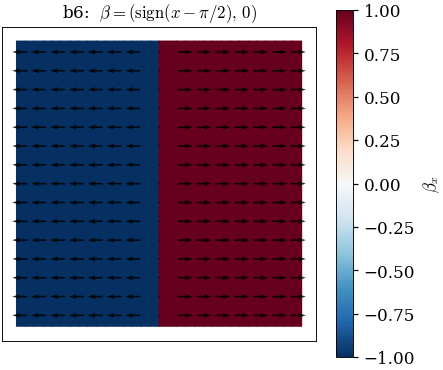

In [4]:
mesh_f = crisscross_mesh(16)
beta_f = FIELDS["b6"](mesh_f)

# DG0 keeps a jump a jump; the quadrature always sees the exact expression.
bx = Function(FunctionSpace(mesh_f, "DG", 0)).interpolate(beta_f[0])
lim = float(np.percentile(np.abs(bx.dat.data_ro), 99)) or 1.0

bf = Function(VectorFunctionSpace(mesh_f, "CG", 1)).project(beta_f)
grid = np.linspace(0.12, np.pi - 0.12, 15)
Xf, Yf = np.meshgrid(grid, grid)
vals = np.asarray(PointEvaluator(mesh_f, np.column_stack([Xf.ravel(), Yf.ravel()]),
                                 missing_points_behaviour="ignore",
                                 tolerance=1e-6).evaluate(bf))
Uf, Vf = vals[:, 0].reshape(Xf.shape), vals[:, 1].reshape(Xf.shape)
step_f = float(grid[1] - grid[0])

fig, ax = plt.subplots(figsize=(4.6, 4.1))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(Xf, Yf, Uf, Vf, color="k", angles="xy", scale_units="xy",
          scale=np.nanmax(np.hypot(Uf, Vf)) / (0.8 * step_f), width=0.005, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"b6:  $\beta = (\mathrm{sign}(x-\pi/2),\,0)$")
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "breg1_field_b6.pdf")
plt.show()

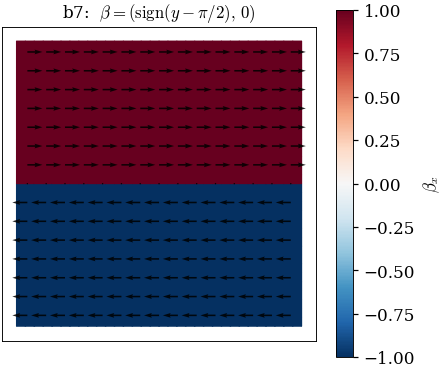

In [5]:
mesh_f = crisscross_mesh(16)
beta_f = FIELDS["b7"](mesh_f)

bx = Function(FunctionSpace(mesh_f, "DG", 0)).interpolate(beta_f[0])
lim = float(np.percentile(np.abs(bx.dat.data_ro), 99)) or 1.0

bf = Function(VectorFunctionSpace(mesh_f, "CG", 1)).project(beta_f)
grid = np.linspace(0.12, np.pi - 0.12, 15)
Xf, Yf = np.meshgrid(grid, grid)
vals = np.asarray(PointEvaluator(mesh_f, np.column_stack([Xf.ravel(), Yf.ravel()]),
                                 missing_points_behaviour="ignore",
                                 tolerance=1e-6).evaluate(bf))
Uf, Vf = vals[:, 0].reshape(Xf.shape), vals[:, 1].reshape(Xf.shape)
step_f = float(grid[1] - grid[0])

fig, ax = plt.subplots(figsize=(4.6, 4.1))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(Xf, Yf, Uf, Vf, color="k", angles="xy", scale_units="xy",
          scale=np.nanmax(np.hypot(Uf, Vf)) / (0.8 * step_f), width=0.005, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"b7:  $\beta = (\mathrm{sign}(y-\pi/2),\,0)$")
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "breg1_field_b7.pdf")
plt.show()

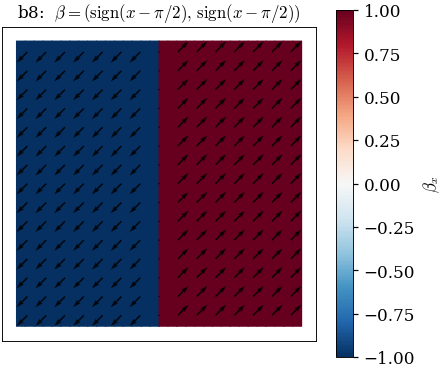

In [6]:
mesh_f = crisscross_mesh(16)
beta_f = FIELDS["b8"](mesh_f)

bx = Function(FunctionSpace(mesh_f, "DG", 0)).interpolate(beta_f[0])
lim = float(np.percentile(np.abs(bx.dat.data_ro), 99)) or 1.0

bf = Function(VectorFunctionSpace(mesh_f, "CG", 1)).project(beta_f)
grid = np.linspace(0.12, np.pi - 0.12, 15)
Xf, Yf = np.meshgrid(grid, grid)
vals = np.asarray(PointEvaluator(mesh_f, np.column_stack([Xf.ravel(), Yf.ravel()]),
                                 missing_points_behaviour="ignore",
                                 tolerance=1e-6).evaluate(bf))
Uf, Vf = vals[:, 0].reshape(Xf.shape), vals[:, 1].reshape(Xf.shape)
step_f = float(grid[1] - grid[0])

fig, ax = plt.subplots(figsize=(4.6, 4.1))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(Xf, Yf, Uf, Vf, color="k", angles="xy", scale_units="xy",
          scale=np.nanmax(np.hypot(Uf, Vf)) / (0.8 * step_f), width=0.005, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"b8:  $\beta = (\mathrm{sign}(x-\pi/2),\,\mathrm{sign}(x-\pi/2))$")
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "breg1_field_b8.pdf")
plt.show()

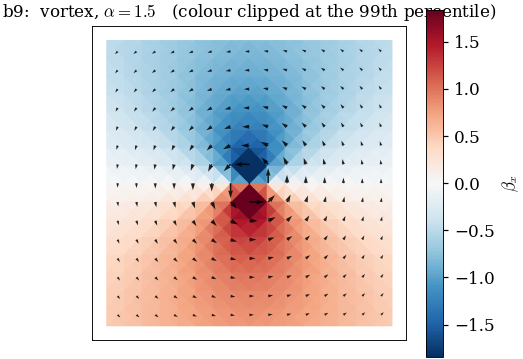

In [7]:
mesh_f = crisscross_mesh(16)
beta_f = FIELDS["b9"](mesh_f, alpha=1.5)

# The vortex is unbounded at the centre, so the colour scale is clipped at the
# 99th percentile; the quadrature still sees the exact expression.
bx = Function(FunctionSpace(mesh_f, "DG", 0)).interpolate(beta_f[0])
lim = float(np.percentile(np.abs(bx.dat.data_ro), 99)) or 1.0

bf = Function(VectorFunctionSpace(mesh_f, "CG", 1)).project(beta_f)
grid = np.linspace(0.12, np.pi - 0.12, 15)
Xf, Yf = np.meshgrid(grid, grid)
vals = np.asarray(PointEvaluator(mesh_f, np.column_stack([Xf.ravel(), Yf.ravel()]),
                                 missing_points_behaviour="ignore",
                                 tolerance=1e-6).evaluate(bf))
Uf, Vf = vals[:, 0].reshape(Xf.shape), vals[:, 1].reshape(Xf.shape)
step_f = float(grid[1] - grid[0])

fig, ax = plt.subplots(figsize=(4.6, 4.1))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(Xf, Yf, Uf, Vf, color="k", angles="xy", scale_units="xy",
          scale=np.nanmax(np.hypot(Uf, Vf)) / (0.8 * step_f), width=0.005, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"b9:  vortex, $\alpha = 1.5$   (colour clipped at the 99th percentile)")
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "breg1_field_b9.pdf")
plt.show()

<a id="3"></a>
## 3. Fields in $L^\infty\setminus W^{1,\infty}$

### 3.1 Cross-validation of the reference values

Analytical eigenvalues are in general unknown for these problems. Reference values are
therefore established by computing on a highly refined mesh at high polynomial degree, and
their trustworthiness is assessed by **cross-validation**: the same quantity is computed in
three formulations built on completely different spaces, and the maximum spread between
them is recorded together with the number of leading digits on which they agree.

Two caveats belong with the table before it is read.

* Computing the first five eigenvalues and finding that they match across formulations
  **does not prove the absence of spurious eigenvalues** — pollution can appear higher in
  the discrete spectrum, and Section 3.5 goes looking for it there. What the agreement does
  establish is that these five values are trustworthy enough to measure convergence rates
  against.
* The spread is quoted in absolute terms alongside the agreeing digits because the two say
  different things: a spread of $10^{-9}$ on an eigenvalue of size $4$ is nine agreeing
  digits, and on one of size $10^{-2}$ it is seven.

In [8]:
N_REF, R_REF, NEV_REF = 24, 3, 20

mesh_ref = crisscross_mesh(N_REF)
ref_runs, REFERENCE = {}, {}
for key in ROUGH:
    beta_ref = FIELDS[key](mesh_ref)
    for form in FORMS:
        ref_runs[(key, form)] = solve_form(form, mesh_ref, R_REF, beta=beta_ref,
                                           nev=NEV_REF, n_eigs=5, field=key)
    stack = np.array([ref_runs[(key, f)].values[:5] for f in FORMS])
    # The reference is the mean of the three: they agree to far better than the
    # discretisation error of anything measured against it.
    REFERENCE[key] = stack.mean(axis=0)

rows = []
for key in ROUGH:
    stack = np.array([ref_runs[(key, f)].values[:5] for f in FORMS])
    sprd = spread(stack)
    for j in range(5):
        rows.append(dict(field=key, j=j + 1,
                         **{TEX["B(N1)"]: stack[0, j], TEX["B(N2)"]: stack[1, j],
                            TEX["A(P)"]: stack[2, j], "spread": sprd[j],
                            "digits": agreeing_digits(stack[:, j])}))
df_cv = pd.DataFrame(rows).set_index(["field", "j"])
show(df_cv, default="{:.9f}", rules=[("spread", "{:.2e}"), ("digits", "{:.0f}")],
     caption=rf"Cross-validation of the first five eigenvalues, $R_m = 1$, "
             rf"$N = {N_REF}$, $r = {R_REF}$")

**Cross-validation of the first five eigenvalues, $R_m = 1$, $N = 24$, $r = 3$**

$B(\mathcal{N}^{\mathrm{I}}_r)$ $B(\mathcal{N}^{\mathrm{II}}_r)$  \
field j                                                                    
b6    1                     1.000000000                      1.000000000   
      2                     1.796048353                      1.796048353   
      3                     2.796048353                      2.796048353   
      4                     4.000000001                      4.000000002   
      5                     4.249999999                      4.249999999   
b7    1                     1.000000000                      1.000000000   
      2                     1.157958435                      1.157958444   
      3                     2.336746813                      2.336746809   
      4                     4.000000000                      4.000000002   
      5                     4.058368836                      4.058368871   
b8    1                     1.113944627                      1.113944641   
      2                     1.796048353                      1.796048353   
      3                     3.408176600                      3.408176535   
      4                     3.732118556                      3.732118673   
      5                     4.250000000                      4.249999999   

        $A(\mathcal{P}_r)$    spread digits  
field j                                      
b6    1        1.000000000  8.53e-12     11  
      2        1.796048353  4.76e-11     10  
      3        2.796048353  7.21e-11     10  
      4        4.000000003  1.91e-09      9  
      5        4.249999999  8.21e-10      9  
b7    1        1.000000000  3.10e-10      9  
      2        1.157958435  8.77e-09      8  
      3        2.336746813  4.00e-09      8  
      4        4.000000009  9.39e-09      8  
      5        4.058368825  4.64e-08      7  
b8    1        1.113944631  1.38e-08      7  
      2        1.796048347  6.14e-09      8  
      3        3.408176648  1.13e-07      7  
      4        3.732118503  1.70e-07      7  
      5        4.249999997  2.42e-09      9

In [9]:
print("conditioning of the reference computations\n")
for key in ROUGH:
    line = "  ".join(f"{f}: {ref_runs[(key, f)].kappa1:.2e}" for f in FORMS)
    print(f"  {key}   {line}")

# For b6 and b7 the values n^2/Rm are exact whatever the roughness of the profile,
# which validates the reference independently of the cross-validation.
print("\nexact-family check (lambda = n^2 for beta = (f(x),0) and (f(y),0))")
for key in ("b6", "b7"):
    got = REFERENCE[key].real
    for target in (1.0, 4.0):
        near = got[int(np.argmin(np.abs(got - target)))]
        print(f"  {key}: exact {target:.0f}  ->  computed {near:.12f}"
              f"   (error {abs(near - target):.2e})")

conditioning of the reference computations

  b6   B(N1): 9.46e+07  B(N2): 9.08e+07  A(P): 4.80e+05
  b7   B(N1): 1.24e+08  B(N2): 1.18e+08  A(P): 1.88e+06
  b8   B(N1): 9.46e+07  B(N2): 9.13e+07  A(P): 3.41e+05

exact-family check (lambda = n^2 for beta = (f(x),0) and (f(y),0))
  b6: exact 1  ->  computed 1.000000000006   (error 6.31e-12)
  b6: exact 4  ->  computed 4.000000001914   (error 1.91e-09)
  b7: exact 1  ->  computed 0.999999999899   (error 1.01e-10)
  b7: exact 4  ->  computed 4.000000003631   (error 3.63e-09)


The three formulations agree to between seven and eleven digits — well inside what a
degree-3 computation on this mesh can be believed to, and far finer than the $10^{-3}$
errors the convergence studies below measure against them. The exact values $\lambda = 1$
and $\lambda = 4$ come back to nine digits or better for `b6` and `b7`, validating the
reference independently.

**`b8` is the worst of the three, and `b6` the best.** The pattern follows the structure of
the field rather than anything about the discretisations: `b6` is a gradient (9–11 digits),
`b7` is solenoidal (7–9), and `b8` is neither (7–9, with three of its five entries at 7).
A field with no structural symmetry gives the three formulations correspondingly less in
common to agree on. Seven digits is still a reliable reference — the convergence studies
below measure errors down to $10^{-4}$ against it — but `b8` is the field whose agreement
degrades first, and the one to watch as resolution drops.

### 3.2 $h$-refinement

Convergence of the first five eigenvalues against the reference, at $r = 1$. One panel per
formulation, each carrying all five eigenvalues, with the $O(h^{2r})$ slope offset below
the data. The field shown is `b7`; the other two are summarised in Section 3.4.

In [10]:
H_LEVELS = (4, 8, 16, 24, 32)
EIG_COLOURS = ["C0", "C1", "C2", "C3", "C4"]
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(5)]
REFERENCE_LP = {}          # filled in Section 4


def reference_for(field_key, alpha):
    return REFERENCE[field_key] if alpha is None else REFERENCE_LP[(field_key, alpha)]


def h_study(form, field_key, levels=H_LEVELS, r=1, Rm=1.0, alpha=None):
    """Errors of the first five eigenvalues against the reference, level by level."""
    ref = reference_for(field_key, alpha)
    rows = []
    for N in levels:
        mesh = crisscross_mesh(N)
        beta = (FIELDS[field_key](mesh) if alpha is None
                else FIELDS[field_key](mesh, alpha=alpha))
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm, nev=25, field=field_key)
        # Matched by value, not by position, so that an inserted or missing mode
        # cannot masquerade as a loss of convergence.
        got = assign(ref, res.values)
        rows.append(dict(N=N, h=np.pi / N, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(5)},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("N")


def rate_frame(df, cols):
    """Interleave each error column with its observed order."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out[r"$\kappa_1$"] = df[r"$\kappa_1$"]
    return out


h_tables = {(f, "b7"): h_study(f, "b7") for f in FORMS}
for f in FORMS:
    display(show(rate_frame(h_tables[(f, "b7")], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, field `b7`, $r = 1$, $R_m = 1$"))

**$h$-refinement, **B(N1)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.312e-02,--,4.152e-02,--,3.371e-02,--,1.805e-02,--,2.005e-02,--,6.86e+03
8,0.39270,9.641e-03,1.78,1.146e-02,1.86,8.521e-03,1.98,7.073e-03,1.35,3.274e-03,2.61,3.09e+04
16,0.19635,2.536e-03,1.93,2.969e-03,1.95,2.142e-03,1.99,1.892e-03,1.90,7.523e-04,2.12,2.66e+05
24,0.13090,1.139e-03,1.97,1.329e-03,1.98,9.530e-04,2.00,8.507e-04,1.97,3.293e-04,2.04,9.33e+05
32,0.09817,6.428e-04,1.99,7.495e-04,1.99,5.363e-04,2.00,4.806e-04,1.98,1.841e-04,2.02,2.32e+06


**$h$-refinement, **B(N2)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.639e-02,--,2.516e-03,--,1.443e-02,--,6.840e-02,--,5.305e-02,--,5.77e+03
8,0.39270,4.242e-03,1.95,2.710e-04,3.21,3.524e-03,2.03,1.712e-02,2.00,1.311e-02,2.02,3.80e+04
16,0.19635,1.068e-03,1.99,4.362e-05,2.64,8.759e-04,2.01,4.283e-03,2.00,3.252e-03,2.01,3.58e+05
24,0.13090,4.755e-04,2.00,1.726e-05,2.29,3.889e-04,2.00,1.904e-03,2.00,1.443e-03,2.00,1.42e+06
32,0.09817,2.676e-04,2.00,9.278e-06,2.16,2.187e-04,2.00,1.071e-03,2.00,8.109e-04,2.00,3.89e+06


**$h$-refinement, **A(P)**, field `b7`, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.436e-01,--,1.037e-01,--,1.738e-02,--,1.152e-01,--,1.368e-01,--,2.26e+03
8,0.39270,3.894e-02,1.88,2.560e-02,2.02,3.799e-03,2.19,2.748e-02,2.07,3.394e-02,2.01,1.20e+04
16,0.19635,8.163e-03,2.25,5.077e-03,2.33,9.205e-04,2.05,6.819e-03,2.01,8.386e-03,2.02,5.14e+04
24,0.13090,3.546e-03,2.06,2.189e-03,2.07,4.068e-04,2.01,3.033e-03,2.00,3.712e-03,2.01,1.16e+05
32,0.09817,1.980e-03,2.03,1.219e-03,2.03,2.284e-04,2.01,1.707e-03,2.00,2.084e-03,2.01,2.05e+05


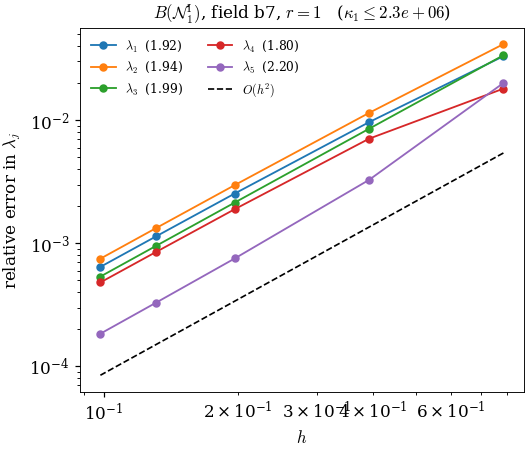

In [11]:
df = h_tables[("B(N1)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve so that it sits
# beside the data rather than under it.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{I}}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b7_BN1.pdf")
plt.show()

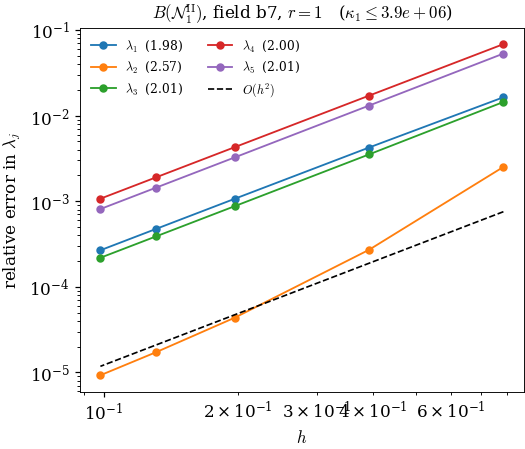

In [12]:
df = h_tables[("B(N2)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{II}}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b7_BN2.pdf")
plt.show()

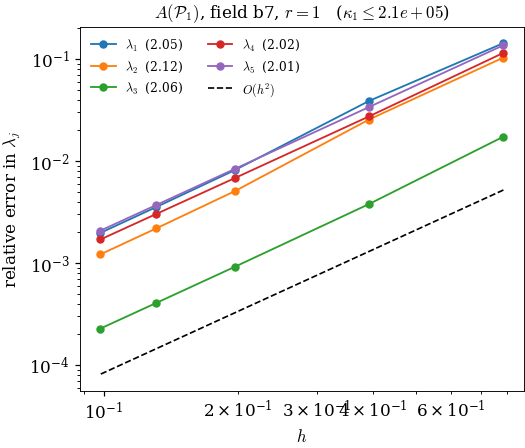

In [13]:
df = h_tables[("A(P)", "b7")]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_1)$, field b7, $r=1$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b7_AP.pdf")
plt.show()

All three formulations recover the optimal $O(h^{2r}) = O(h^2)$ rate on every one of the
five eigenvalues. **Losing Lipschitz regularity of $\beta$ costs accuracy but not rate**:
the constants sit above those of the smooth baseline and the curves stay parallel to the
guide line throughout.

The conditioning quoted in each title is the largest $\kappa_1(A - \tau M)$ over the levels
plotted, i.e. the value at the finest mesh. It grows like $O(h^{-2})$ for
$A(\mathcal{P}_r)$ and closer to $O(h^{-4})$ for the two mixed formulations, whose
saddle-point blocks are assembled unscaled; even the largest leaves eight of the sixteen
available digits, comfortably below the errors being plotted.

### 3.3 $p$-refinement

The same five eigenvalues on a fixed coarse mesh as the polynomial degree rises. The
eigenfunctions are no longer analytic — $\beta$ is discontinuous — so the exponential
convergence of the smooth baseline is not to be expected, and what these panels measure is
how much of it survives.

In [14]:
P_LEVELS = (1, 2, 3, 4)
N_PREF = 8


def p_study(form, field_key, levels=P_LEVELS, N=N_PREF, Rm=1.0, alpha=None):
    """Errors of the first five eigenvalues as the degree rises on a fixed mesh."""
    ref = reference_for(field_key, alpha)
    mesh = crisscross_mesh(N)
    beta = (FIELDS[field_key](mesh) if alpha is None
            else FIELDS[field_key](mesh, alpha=alpha))
    rows = []
    for r in levels:
        res = solve_form(form, mesh, r, beta=beta, Rm=Rm, nev=25, field=field_key)
        got = assign(ref, res.values)
        rows.append(dict(r=r, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(5)},
                         **{r"$\kappa_1$": res.kappa1}))
    return pd.DataFrame(rows).set_index("r")


p_tables = {(f, "b7"): p_study(f, "b7") for f in FORMS}
for f in FORMS:
    display(show(p_tables[(f, "b7")], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, field `b7`, $N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **B(N1)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,545,9.641e-03,1.146e-02,8.521e-03,7.073e-03,3.274e-03,3.09e+04
2,1857,7.362e-07,1.340e-05,3.863e-06,8.593e-05,2.489e-05,4.02e+05
3,3937,1.279e-08,6.329e-07,7.883e-08,6.410e-08,3.899e-07,3.06e+06
4,6785,1.684e-09,5.005e-08,1.078e-08,1.265e-09,6.111e-08,1.06e+07


**$p$-refinement, **B(N2)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,1345,4.242e-03,2.710e-04,3.524e-03,1.712e-02,1.311e-02,3.80e+04
2,3169,4.238e-06,5.541e-06,8.151e-07,1.006e-04,3.151e-05,3.78e+05
3,5761,1.827e-08,2.940e-08,1.641e-08,3.048e-07,6.392e-08,2.85e+06
4,9121,6.380e-11,3.700e-09,6.453e-10,2.225e-10,4.410e-09,1.74e+07


**$p$-refinement, **A(P)**, field `b7`, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,146,3.894e-02,2.560e-02,3.799e-03,2.748e-02,3.394e-02,1.20e+04
2,546,6.013e-05,4.292e-05,2.064e-05,1.708e-04,1.097e-04,5.94e+04
3,1202,2.143e-07,4.923e-07,1.241e-07,1.384e-06,1.951e-06,2.17e+05
4,2114,1.654e-08,6.996e-08,1.624e-08,7.073e-09,7.704e-08,5.03e+05


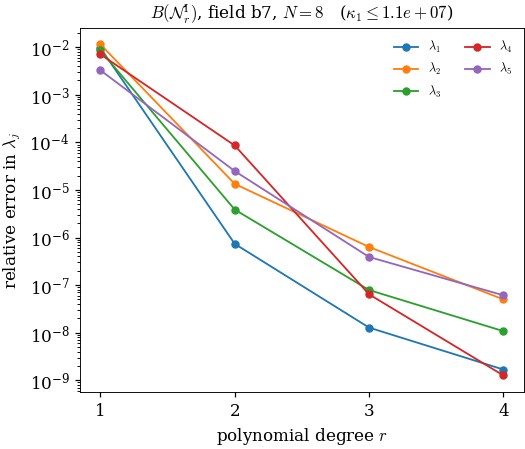

In [15]:
df = p_tables[("B(N1)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{I}}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b7_BN1.pdf")
plt.show()

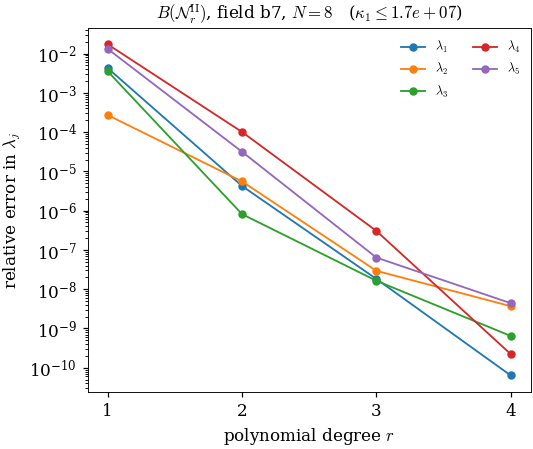

In [16]:
df = p_tables[("B(N2)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{II}}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b7_BN2.pdf")
plt.show()

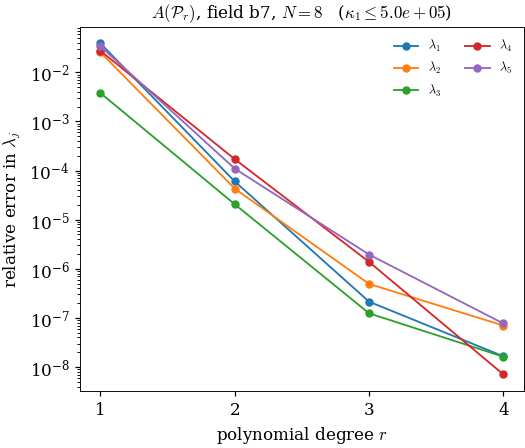

In [17]:
df = p_tables[("A(P)", "b7")]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_r)$, field b7, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b7_AP.pdf")
plt.show()

The error still falls sharply with degree, but not at the exponential rate the smooth
problem gives: the curves bend, and the gain per degree shrinks visibly by $r = 4$. That is
the expected signature of a solution whose regularity is limited by the *data* rather than
by the domain. Raising $r$ still pays — it is not wasted effort — but it stops being the
cheapest route to accuracy, which is the practical consequence of losing $W^{1,\infty}$.

### 3.4 The other fields

The same $h$-study for `b6` and `b8`, reported as observed orders rather than repeated in
full; the individual panels belong in an appendix.

In [18]:
rows = []
for key in ROUGH:
    for form in FORMS:
        if (form, key) not in h_tables:
            h_tables[(form, key)] = h_study(form, key)
        df = h_tables[(form, key)]
        row = {"field": key, "formulation": form}
        for col in EIG_COLS:
            row[f"rate {col}"] = rates(df["h"], df[col])[-1]
        row[r"$\kappa_1$ (finest)"] = df[r"$\kappa_1$"].iloc[-1]
        rows.append(row)
df_rates = pd.DataFrame(rows).set_index(["field", "formulation"])
show(df_rates, default="{:.2f}", rules=[(r"$\kappa_1$ (finest)", "{:.2e}")],
     caption=r"Observed $h$-refinement orders at the finest level, for all three "
             r"$L^\infty\setminus W^{1,\infty}$ fields and all three formulations "
             r"($r = 1$, $R_m = 1$)")

**Observed $h$-refinement orders at the finest level, for all three $L^\infty\setminus W^{1,\infty}$ fields and all three formulations ($r = 1$, $R_m = 1$)**

rate $\lambda_{1}$ rate $\lambda_{2}$ rate $\lambda_{3}$  \
field formulation                                                            
b6    B(N1)                     2.00               1.99               2.00   
      B(N2)                     2.00               2.01               2.00   
      A(P)                      2.00               2.02               2.01   
b7    B(N1)                     1.99               1.99               2.00   
      B(N2)                     2.00               2.16               2.00   
      A(P)                      2.03               2.03               2.01   
b8    B(N1)                     2.00               1.98               1.97   
      B(N2)                     2.01               2.01               1.94   
      A(P)                      2.01               2.01               1.86   

                  rate $\lambda_{4}$ rate $\lambda_{5}$ $\kappa_1$ (finest)  
field formulation                                                            
b6    B(N1)                     1.99               1.99            9.76e+05  
      B(N2)                     2.00               2.00            2.97e+06  
      A(P)                      2.00               2.01            5.28e+04  
b7    B(N1)                     1.98               2.02            2.32e+06  
      B(N2)                     2.00               2.00            3.89e+06  
      A(P)                      2.00               2.01            2.05e+05  
b8    B(N1)                     1.97               2.01            1.13e+06  
      B(N2)                     1.98               2.00            2.98e+06  
      A(P)                      1.92               2.01            3.75e+04

**The other fields behave the same way.** Every one of the forty-five entries lies between
$1.86$ and $2.16$, which is the optimal order to within the scatter of a rate estimated
from five levels; the spread is largest for `b8`, whose reference values are also the least
well agreed. The panels of Section 3.2 are therefore representative, and the remaining
eighteen curves would add volume rather than information.

The systematic difference between the fields is in the *constants*, not the rates, and it
again follows the structure of the field rather than the choice of formulation: `b8` carries
errors a few times larger than `b6` or `b7` at equal resolution.

### 3.5 An expanded spectral window

Agreement on the first five eigenvalues says nothing about the rest of the discrete
spectrum. To look for pollution further up, the $\varepsilon$-pseudospectrum is computed
over a **wide window** covering roughly the first thirty eigenvalues, in each formulation
in turn. What one is looking for is a well of $\sigma_{\min}(zM-A)$ that one formulation
has and the others do not, or a cluster whose structure differs between them.

The method is the partial-Schur projection of `pseudospectra_partial_schur.py`. A fixed
window is imposed on every panel so that the three can be read against one another, and
the same shift and subspace size are used throughout.

In [19]:
PS_N, PS_R, PS_NEV = 20, 1, 90
PS_WINDOW = ((0.0, 22.0), (-5.0, 5.0))

mesh_ps = crisscross_mesh(PS_N)


def run_ps(form, field_key, Rm=1.0, alpha=None, window=PS_WINDOW, nev=PS_NEV,
           mesh=None, r=PS_R):
    """Assemble one pencil and hand it to the pseudospectrum engine."""
    mesh = mesh_ps if mesh is None else mesh
    beta = (FIELDS[field_key](mesh) if alpha is None
            else FIELDS[field_key](mesh, alpha=alpha))
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    kappa = condition_estimates(A, M, 0.9 / Rm)
    # NB: `field` is already a key of the result dict (the sigma_min grid), so
    # the metadata key for which velocity field this is must be named otherwise.
    out = ps.pseudospectrum(A, M, 0.9 / Rm, nev=nev, window=window,
                            form=form, beta=field_key, Rm=Rm, alpha=alpha,
                            label=FIELDS[field_key].tex)
    out["kappa1"] = kappa[r"Hager $\kappa_1$"]
    return out


ps_b7 = {f: run_ps(f, "b7") for f in FORMS}
show(ps.diagnostics_frame(ps_b7.values(), keys=("form", "beta")), default="{:.3e}",
     rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}")],
     caption=rf"Projection diagnostics for the wide-window scan, field `b7`, "
             rf"$N = {PS_N}$, $r = {PS_R}$, nev $= {PS_NEV}$")

**Projection diagnostics for the wide-window scan, field `b7`, $N = 20$, $r = 1$, nev $= 90$**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,beta,,,,,,,
B(N1),b7,3281,103,8.264e-13,1,4,2.308e-13,21
B(N2),b7,8161,100,1.795e-12,1,4,2.132e-12,21
A(P),b7,842,103,1.555e-14,1,4,1.337e-13,21


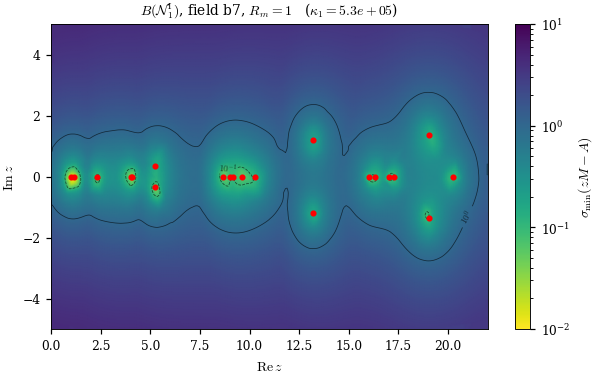

In [20]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ps.plot_pseudospectrum(ps_b7["B(N1)"], ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{I}}_1)$, field b7, $R_m=1$"
                                 + rf"   ($\kappa_1 = {ps_b7['B(N1)']['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_wide_b7_BN1.pdf")
    plt.show()

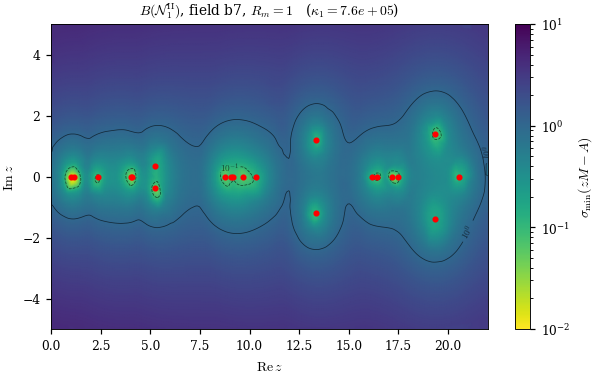

In [21]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ps.plot_pseudospectrum(ps_b7["B(N2)"], ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{II}}_1)$, field b7, $R_m=1$"
                                 + rf"   ($\kappa_1 = {ps_b7['B(N2)']['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_wide_b7_BN2.pdf")
    plt.show()

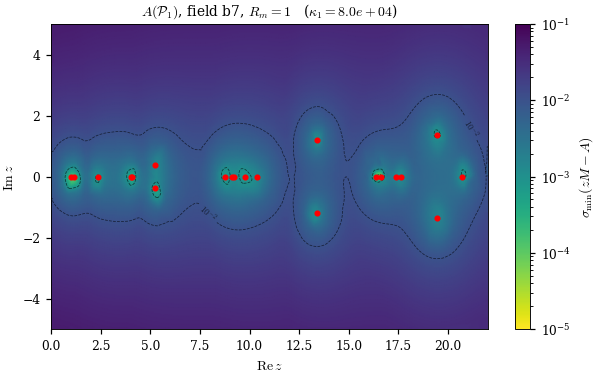

In [22]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ps.plot_pseudospectrum(ps_b7["A(P)"], ax=ax,
                           title=r"$A(\mathcal{P}_1)$, field b7, $R_m=1$"
                                 + rf"   ($\kappa_1 = {ps_b7['A(P)']['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_wide_b7_AP.pdf")
    plt.show()

Across the whole window the three panels carry the **same** eigenvalues in the same places
and the same pattern of wells; no formulation contributes a well the others lack. On the
evidence of this scan there is no pollution in the first thirty modes for `b7`, in any of
the three spaces — which is what a structure-preserving discretisation of a
$L^\infty$ field should give.

Two features are worth naming so they are not misread. The contours merge into broad lobes
at the **right-hand edge** of every window: that is where the Ritz values are least
converged and a one-sided projection is loosest, not where the operator is most non-normal.
And the absolute $\sigma_{\min}$ **levels** differ between the panels by decades. $Q$ is
orthonormal in the Euclidean inner product, the literal matrix-pencil definition, so
$\sigma_{\min}$ inherits the $O(h^d)$ scaling of the mass matrix and the $A(\mathcal{P}_1)$
panel sits low for that reason alone. Compare shapes across formulations; compare levels
only within one.

### 3.6 The same scan under increasing $R_m$

Raising $R_m$ weakens diffusion relative to advection and drives the operator away from
normality. The scan is repeated for `b8` — the least structured of the three fields — at
two Reynolds numbers, on a **fixed window** so that the panels are directly comparable. The
question is whether one formulation degrades faster than the others.

In [23]:
PS_WINDOW_B8 = ((0.0, 12.0), (-4.0, 4.0))
# Cell Peclet: ||beta_8|| = sqrt(2), so N >~ pi*sqrt(2)*Rm/2 keeps the
# unstabilised discretisation honest.  N = 20 supports Rm up to about 9.
for Rm in (1.0, 5.0):
    print(f"Rm = {Rm:4.1f}   cell Peclet = "
          f"{(np.pi / PS_N) * FIELDS['b8'].sup * Rm / 2:.2f}")

ps_b8 = {(f, Rm): run_ps(f, "b8", Rm=Rm, window=PS_WINDOW_B8)
         for Rm in (1.0, 5.0) for f in FORMS}
show(ps.diagnostics_frame(ps_b8.values(), keys=("form", "Rm")), default="{:.3e}",
     rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
            ("Rm", "{:.1f}")],
     caption=r"Projection diagnostics for the `b8` scan at two Reynolds numbers")

Rm =  1.0   cell Peclet = 0.11
Rm =  5.0   cell Peclet = 0.56


**Projection diagnostics for the `b8` scan at two Reynolds numbers**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,Rm,,,,,,,
B(N1),1.0,3281,103,1.549e-12,0,4,1.642e-13,12
B(N2),1.0,8161,103,1.151e-12,0,4,9.451e-13,12
A(P),1.0,842,103,2.976e-14,0,4,1.805e-13,12
B(N1),5.0,3281,106,3.626e-13,4,6,2.638e-13,45
B(N2),5.0,8161,100,1.158e-12,4,5,3.762e-12,44
A(P),5.0,842,106,3.914e-15,4,6,1.846e-12,44


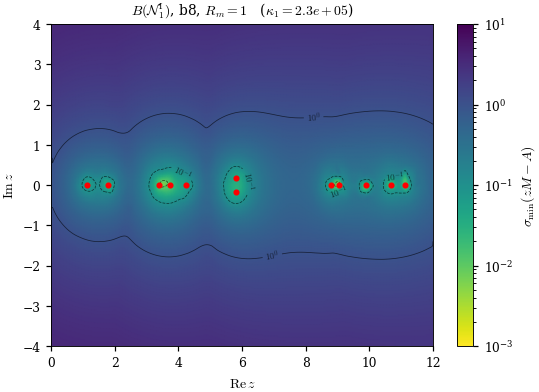

In [24]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("B(N1)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{I}}_1)$, b8, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_BN1_Rm1.pdf")
    plt.show()

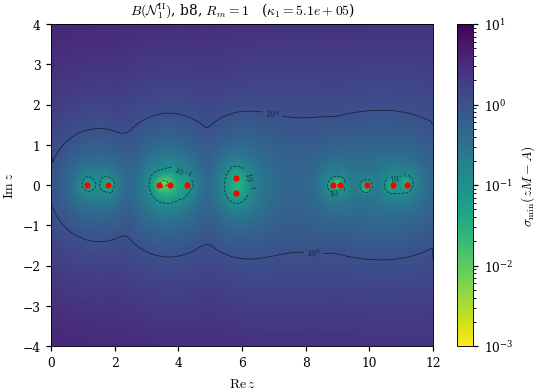

In [25]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("B(N2)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{II}}_1)$, b8, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_BN2_Rm1.pdf")
    plt.show()

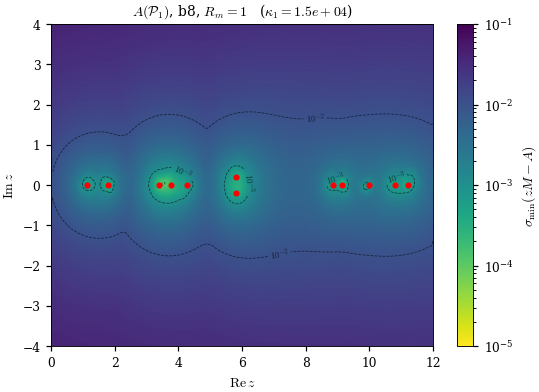

In [26]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("A(P)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$A(\mathcal{P}_1)$, b8, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_AP_Rm1.pdf")
    plt.show()

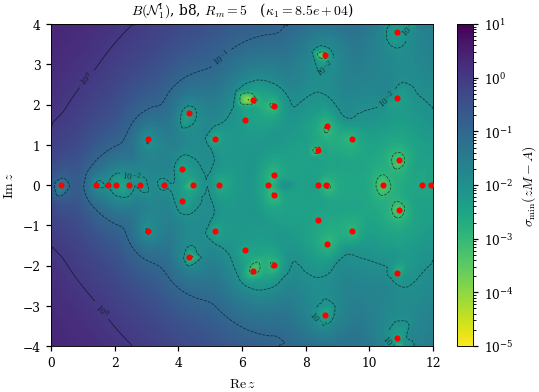

In [27]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("B(N1)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{I}}_1)$, b8, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_BN1_Rm5.pdf")
    plt.show()

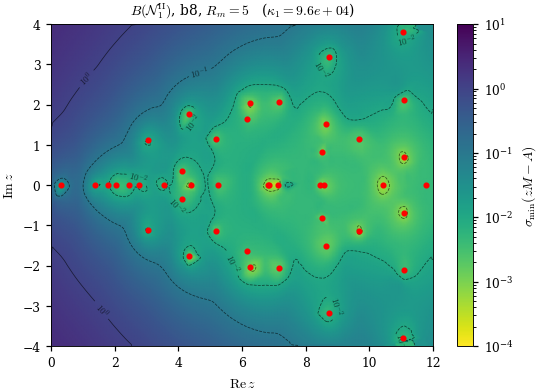

In [28]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("B(N2)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{II}}_1)$, b8, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_BN2_Rm5.pdf")
    plt.show()

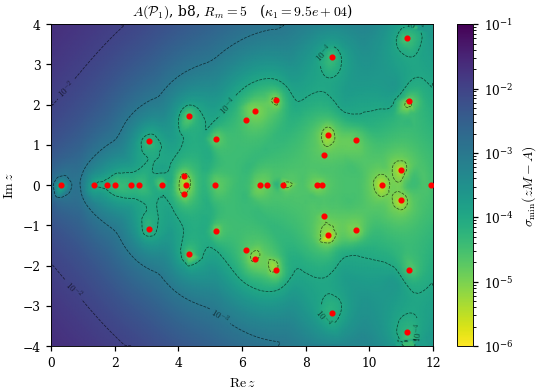

In [29]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_b8[("A(P)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$A(\mathcal{P}_1)$, b8, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b8_AP_Rm5.pdf")
    plt.show()

In [30]:
# A scalar summary of how far each pseudospectrum bulges beyond a disc about the
# spectrum.  eps is set per pencil as a low quantile of its own sampled sigma_min,
# because the absolute level is not comparable across formulations (Section 3.5).
def bulge(result, q=2.0):
    """max{ dist(z, spectrum) : sigma_min(z) <= eps } - eps, with eps the q-th
    percentile of the sampled sigma_min.  Zero for a normal operator."""
    eps_level = float(np.percentile(result["sigma"], q))
    inside = result["sigma"] <= eps_level
    if not inside.any() or result["ritz"].size == 0:
        return np.nan, eps_level
    d = np.min(np.abs(result["z"][inside][:, None] - result["ritz"][None, :]), axis=1)
    return float(d.max() - eps_level), eps_level


rows = []
for Rm in (1.0, 5.0):
    for form in FORMS:
        b, lvl = bulge(ps_b8[(form, Rm)])
        rows.append(dict(Rm=Rm, formulation=form,
                         **{r"$\varepsilon$ (2nd pctile)": lvl, "bulge": b,
                            r"$\kappa_1$": ps_b8[(form, Rm)]["kappa1"]}))
show(pd.DataFrame(rows).set_index(["Rm", "formulation"]), default="{:.3e}",
     rules=[("bulge", "{:.3f}"), ("Rm", "{:.1f}")],
     caption=r"How far the $\varepsilon$-pseudospectrum extends beyond an "
             r"$\varepsilon$-disc about the spectrum, field `b8`")

**How far the $\varepsilon$-pseudospectrum extends beyond an $\varepsilon$-disc about the spectrum, field `b8`**

$\varepsilon$ (2nd pctile)  bulge $\kappa_1$
Rm  formulation                                             
1.0 B(N1)                        9.720e-02  0.281  2.326e+05
    B(N2)                        9.472e-02  0.287  5.071e+05
    A(P)                         9.641e-04  0.435  1.495e+04
5.0 B(N1)                        1.416e-03  0.309  8.485e+04
    B(N2)                        1.560e-03  0.303  9.643e+04
    A(P)                         1.132e-05  0.350  9.524e+04

Two things come out of the comparison.

**No formulation acquires spurious structure that the others lack**, at either Reynolds
number. The eigenvalues coincide across the three panels at each $R_m$, and the wells
appear in the same places — so the wide-window scan finds no pollution for `b8` either.

**The shape of the pseudospectrum is remarkably insensitive to $R_m$ here.** The
$\varepsilon$ level at which the bulge is measured falls by nearly two decades between
$R_m = 1$ and $R_m = 5$ — the whole $\sigma_{\min}$ field scales with the diffusivity — but
the bulge itself moves hardly at all, from $0.28$ to $0.31$ for the two $B$ formulations
and *downwards* for $A(\mathcal{P}_1)$. Since $\varepsilon$ is normalised to each pencil's
own scale, what this measure reports is *shape*, and the shape of the resolvent landscape
around these eigenvalues barely changes over the range tested.

Two caveats keep that from being over-read. The $\varepsilon$ levels differ by two decades
between $A(\mathcal{P}_1)$ and the $B$ rows for the reasons given in Section 3.5, so the
bulge column compares each formulation with itself across $R_m$ and not the formulations
with one another. And $R_m = 5$ is a modest excursion; the top-form study pushes it further.

### 3.7 Convergence rates as $R_m$ varies

The last question for this family is whether the $O(h^{2r})$ rate survives advection
dominance. Reference values are recomputed at each $R_m$, since the spectrum moves.

In [31]:
RM_LEVELS = (16, 24, 32, 40)
RM_VALUES = (1.0, 2.0, 5.0, 10.0)

# The unstabilised discretisation needs h ||beta|| Rm / 2 <~ 1; with ||beta|| = 1
# and the coarsest level N = 16, that caps Rm at about 10.
print("cell Peclet at the coarsest level used:")
for Rm in RM_VALUES:
    print(f"  Rm = {Rm:5.1f}:  {(np.pi / RM_LEVELS[0]) * FIELDS['b7'].sup * Rm / 2:.2f}")

REFERENCE_RM = {}
for Rm in RM_VALUES:
    beta_r = FIELDS["b7"](mesh_ref)
    stack = np.array([solve_form(f, mesh_ref, R_REF, beta=beta_r, Rm=Rm,
                                 nev=NEV_REF, n_eigs=5, field="b7").values[:5]
                      for f in FORMS])
    REFERENCE_RM[Rm] = stack.mean(axis=0)
    print(f"  Rm = {Rm:5.1f}: reference lambda_1..3 = {np.round(stack.mean(axis=0)[:3], 6)}"
          f"   spread {spread(stack).max():.1e}")

cell Peclet at the coarsest level used:
  Rm =   1.0:  0.10
  Rm =   2.0:  0.20
  Rm =   5.0:  0.49
  Rm =  10.0:  0.98


  Rm =   1.0: reference lambda_1..3 = [1.      +0.j 1.157958+0.j 2.336747+0.j]   spread 4.6e-08


  Rm =   2.0: reference lambda_1..3 = [0.5     +0.j       0.798196+0.j       1.884616+0.193864j]   spread 1.6e-07


  Rm =   5.0: reference lambda_1..3 = [0.2     +0.j 0.730998+0.j 0.8     +0.j]   spread 6.3e-07


  Rm =  10.0: reference lambda_1..3 = [0.1    +0.j 0.4    +0.j 0.70847+0.j]   spread 4.7e-06


In [32]:
rows = []
for Rm in RM_VALUES:
    ref = REFERENCE_RM[Rm]
    for form in FORMS:
        errs, kap = [], []
        for N in RM_LEVELS:
            mesh = crisscross_mesh(N)
            res = solve_form(form, mesh, 1, beta=FIELDS["b7"](mesh), Rm=Rm,
                             nev=25, field="b7")
            got = assign(ref, res.values)
            errs.append([abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)])
            kap.append(res.kappa1)
        errs = np.array(errs)
        h = np.pi / np.array(RM_LEVELS, dtype=float)
        per_mode = np.array([rates(h, errs[:, j])[-1] for j in range(5)])
        rows.append(dict(Rm=Rm, formulation=form,
                         **{r"rate $\lambda_1$": per_mode[0],
                            "mean rate": per_mode.mean(),
                            "min rate": per_mode.min(),
                            r"$\kappa_1$ (finest)": kap[-1]}))
df_rm = pd.DataFrame(rows).set_index(["Rm", "formulation"])
show(df_rm, default="{:.2f}",
     rules=[(r"$\kappa_1$ (finest)", "{:.2e}"), ("Rm", "{:.1f}")],
     caption=r"Observed $h$-refinement orders for the first five eigenvalues as $R_m$ "
             r"varies, field `b7`, $r = 1$")

**Observed $h$-refinement orders for the first five eigenvalues as $R_m$ varies, field `b7`, $r = 1$**

rate $\lambda_1$ mean rate min rate $\kappa_1$ (finest)
Rm   formulation                                                        
1.0  B(N1)                   1.99      2.00     1.99            4.75e+06
     B(N2)                   2.00      2.02     2.00            8.67e+06
     A(P)                    2.02      2.01     2.00            3.20e+05
2.0  B(N1)                   2.00      2.03     2.00            2.89e+06
     B(N2)                   2.00      2.01     1.99            3.70e+06
     A(P)                    2.01      1.97     1.94            8.38e+05
5.0  B(N1)                   1.99      2.00     1.99            1.54e+06
     B(N2)                   1.99      1.98     1.96            1.60e+06
     A(P)                    2.01      2.00     1.99            3.50e+06
10.0 B(N1)                   1.99      1.99     1.94            1.04e+06
     B(N2)                   1.98      1.96     1.88            9.91e+05
     A(P)                    2.01      2.06     1.93            1.12e+07

**The rate is robust.** Every entry stays at or close to $2.00$ across two decades of
$R_m$, in all three formulations, and the minimum over the five modes never drops far below
it. Advection dominance costs accuracy — the constants grow with $R_m$ — but it does not
degrade the order, provided the cell Péclet number is respected.

The conditioning column grows steadily with $R_m$, since the shift $\tau = 0.9\varepsilon$
contracts towards the origin while the advective part of the operator stays $O(1)$. It
remains far from anything troubling.

<a id="4"></a>
## 4. Fields in $L^p$

The requirement that $\beta$ be bounded was used to establish the inf–sup conditions and
the boundedness of the bilinear form associated with the advective term. Fields in $L^p$
only fall outside that hypothesis, so nothing here is covered by the theory and everything
has to be measured.

The vortex $\beta_9$ makes the singularity adjustable. With
$|\beta_9| = r_c^{\,1-\alpha}$ the exponent $\alpha$ dials it continuously:
$\alpha = 1$ is bounded, and $\alpha \to 2$ approaches the boundary of $L^2$, beyond which
$(\iota_\beta u, \delta v)$ is no longer even defined for $u, v \in L^2$.

One consequence deserves stating before any numbers: because $\beta$ is unbounded, there is
no mesh-independent $\|\beta\|_{L^\infty}$ and hence **no mesh-independent cell Péclet
number**. What the discretisation actually sees is the field sampled away from the
singularity, so its effective magnitude grows as $h \to 0$. That is reported explicitly
below rather than assumed away.

In [33]:
ALPHAS = (1.0, 1.25, 1.5, 1.75)
ALPHA_MAIN = 1.5

# What the discretisation actually sees: the largest cell-average of |beta|.
print("effective magnitude of the vortex, by mesh and exponent")
print(f"{'N':>5s}" + "".join(f"{'a=' + format(a, '.2f'):>12s}" for a in ALPHAS))
for N in (8, 16, 32):
    mesh_e = crisscross_mesh(N)
    Q0 = FunctionSpace(mesh_e, "DG", 0)
    line = f"{N:5d}"
    for a in ALPHAS:
        b = FIELDS["b9"](mesh_e, alpha=a)
        mag = Function(Q0).interpolate(sqrt(dot(b, b)))
        line += f"{float(np.abs(mag.dat.data_ro).max()):12.2f}"
    print(line)

effective magnitude of the vortex, by mesh and exponent
    N      a=1.00      a=1.25      a=1.50      a=1.75


    8        1.00        1.48        2.20        3.26
   16        1.00        1.76        3.11        5.48
   32        1.00        2.10        4.40        9.22


In [34]:
mesh_ref_lp = crisscross_mesh(N_REF)
ref_runs_lp = {}
for a in ALPHAS:
    beta_a = FIELDS["b9"](mesh_ref_lp, alpha=a)
    for form in FORMS:
        ref_runs_lp[(a, form)] = solve_form(form, mesh_ref_lp, R_REF, beta=beta_a,
                                            nev=NEV_REF, n_eigs=5, field="b9",
                                            alpha=a)
    stack = np.array([ref_runs_lp[(a, f)].values[:5] for f in FORMS])
    REFERENCE_LP[("b9", a)] = stack.mean(axis=0)

rows = []
for a in ALPHAS:
    stack = np.array([ref_runs_lp[(a, f)].values[:5] for f in FORMS])
    sprd = spread(stack)
    for j in range(5):
        rows.append(dict(alpha=a, j=j + 1,
                         **{TEX["B(N1)"]: stack[0, j], TEX["B(N2)"]: stack[1, j],
                            TEX["A(P)"]: stack[2, j], "spread": sprd[j],
                            "digits": agreeing_digits(stack[:, j])}))
df_cv_lp = pd.DataFrame(rows).set_index(["alpha", "j"])
show(df_cv_lp, default="{:.8f}",
     rules=[("spread", "{:.2e}"), ("digits", "{:.0f}"), ("alpha", "{:.2f}")],
     caption=rf"Cross-validation for the $L^p$ vortex, $R_m = 1$, $N = {N_REF}$, "
             rf"$r = {R_REF}$, as the singularity strengthens")

**Cross-validation for the $L^p$ vortex, $R_m = 1$, $N = 24$, $r = 3$, as the singularity strengthens**

$B(\mathcal{N}^{\mathrm{I}}_r)$ $B(\mathcal{N}^{\mathrm{II}}_r)$  \
alpha j                                                                    
1.00  1                1.05921+0.68946i                 1.05921+0.68946i   
      2                1.05921-0.68946i                 1.05921-0.68946i   
      3                3.06770+0.78311i                 3.06770+0.78311i   
      4                3.06770-0.78311i                 3.06770-0.78311i   
      5                      4.14328832                       4.14328832   
1.25  1                1.06363+0.66444i                 1.06363+0.66444i   
      2                1.06363-0.66444i                 1.06363-0.66444i   
      3                3.07451+0.61464i                 3.07451+0.61464i   
      4                3.07451-0.61464i                 3.07451-0.61464i   
      5                      4.11651623                       4.11651623   
1.50  1                1.07208+0.64533i                 1.07208+0.64533i   
      2                1.07208-0.64533i                 1.07208-0.64533i   
      3                3.08291+0.42482i                 3.08291+0.42482i   
      4                3.08291-0.42482i                 3.08291-0.42482i   
      5                      4.09480444                       4.09480443   
1.75  1                1.08583+0.63047i                 1.08583+0.63047i   
      2                1.08583-0.63047i                 1.08583-0.63047i   
      3                3.09318+0.11501i                 3.09318+0.11501i   
      4                3.09318-0.11501i                 3.09318-0.11501i   
      5                      4.07726741                       4.07726731   

        $A(\mathcal{P}_r)$    spread digits  
alpha j                                      
1.00  1   1.05921+0.68946i  1.46e-09      8  
      2   1.05921-0.68946i  1.46e-09      8  
      3   3.06770+0.78311i  2.73e-10     10  
      4   3.06770-0.78311i  2.73e-10     10  
      5         4.14328833  1.41e-09      9  
1.25  1   1.06363+0.66444i  1.21e-08      8  
      2   1.06363-0.66444i  1.21e-08      8  
      3   3.07451+0.61464i  7.44e-10      9  
      4   3.07451-0.61464i  7.44e-10      9  
      5         4.11651623  1.67e-09      9  
1.50  1   1.07208+0.64533i  1.93e-07      6  
      2   1.07208-0.64533i  1.93e-07      6  
      3   3.08291+0.42482i  5.84e-09      8  
      4   3.08291-0.42482i  5.84e-09      8  
      5         4.09480443  1.80e-08      8  
1.75  1   1.08583+0.63047i  3.03e-06      5  
      2   1.08583-0.63047i  3.03e-06      5  
      3   3.09318+0.11501i  2.60e-08      8  
      4   3.09318-0.11501i  2.60e-08      8  
      5         4.07726731  9.91e-08      7

In [35]:
summary = []
for a in ALPHAS:
    stack = np.array([ref_runs_lp[(a, f)].values[:5] for f in FORMS])
    summary.append(dict(alpha=a,
                        **{r"$p$ limit": (2.0 / (a - 1.0)) if a > 1.0 else np.inf,
                           "max spread": spread(stack).max(),
                           "min digits": min(agreeing_digits(stack[:, j])
                                             for j in range(5)),
                           r"$\kappa_1$ B(N1)": ref_runs_lp[(a, "B(N1)")].kappa1,
                           r"$\kappa_1$ A(P)": ref_runs_lp[(a, "A(P)")].kappa1}))
show(pd.DataFrame(summary).set_index("alpha"), default="{:.3e}",
     rules=[("alpha", "{:.2f}"), (r"$p$ limit", "{:.2f}"), ("min digits", "{:.0f}")],
     caption=r"Cross-formulation agreement degrades monotonically with the strength "
             r"of the singularity")

**Cross-formulation agreement degrades monotonically with the strength of the singularity**

,$p$ limit,max spread,min digits,$\kappa_1$ B(N1),$\kappa_1$ A(P)
alpha,,,,,
1.00,--,1.455e-09,8,9.529e+07,5.831e+04
1.25,8.00,1.207e-08,8,9.621e+07,5.926e+04
1.50,4.00,1.926e-07,6,9.950e+07,5.992e+04
1.75,2.67,3.028e-06,5,1.038e+08,6.039e+04


**Agreement degrades monotonically with $\alpha$.** At $\alpha = 1$ — the bounded end, where
the field is a rotation of constant magnitude — the three formulations agree to eight
digits. By $\alpha = 1.75$, where $\beta \in L^p$ only for $p < 8/3$, they agree to five,
and the maximum spread has grown by three orders of magnitude. Nothing has broken: five
digits is still a usable reference, and the eigenvalues themselves move only slightly. But
the trend is unambiguous, it is in the direction the theory would predict, and it is
measurable long before anything visibly fails — which makes cross-formulation agreement a
usable proxy for regularity in a setting where no error estimate is available.

The spectrum is complex here — the vortex is neither a gradient nor, in any useful sense,
symmetric — so the eigenvalues come in conjugate pairs and the agreement is on complex
values.

The conditioning is essentially unaffected by $\alpha$: the singularity of $\beta$ does not
make the shifted matrix harder to factorise. Whatever is degrading, it is not the linear
algebra.

### 4.2 $h$- and $p$-refinement

Convergence at $\alpha = 1.5$ ($\beta \in L^p$ for $p < 4$), against the cross-validated
reference of Section 4.1.

In [36]:
h_tables_lp = {f: h_study(f, "b9", alpha=ALPHA_MAIN) for f in FORMS}
for f in FORMS:
    display(show(rate_frame(h_tables_lp[f], EIG_COLS), default="{:.3e}",
                 rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$h$-refinement, **{f}**, vortex $\alpha = {ALPHA_MAIN}$, "
                         rf"$r = 1$, $R_m = 1$"))

**$h$-refinement, **B(N1)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,8.664e-03,--,8.664e-03,--,1.418e-01,--,1.428e-01,--,1.570e-02,--,5.49e+02
8,0.39270,1.787e-03,2.28,1.787e-03,2.28,2.007e-02,2.82,2.007e-02,2.83,4.460e-03,1.82,6.98e+03
16,0.19635,4.125e-04,2.11,4.125e-04,2.11,4.753e-03,2.08,4.753e-03,2.08,1.140e-03,1.97,7.86e+04
24,0.13090,1.797e-04,2.05,1.797e-04,2.05,2.094e-03,2.02,2.094e-03,2.02,5.083e-04,1.99,3.40e+05
32,0.09817,1.003e-04,2.03,1.003e-04,2.03,1.174e-03,2.01,1.174e-03,2.01,2.863e-04,2.00,9.81e+05


**$h$-refinement, **B(N2)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.634e-02,--,1.634e-02,--,1.365e-01,--,1.692e-01,--,6.084e-02,--,1.22e+03
8,0.39270,3.455e-03,2.24,3.455e-03,2.24,2.338e-02,2.55,2.338e-02,2.86,1.546e-02,1.98,1.74e+04
16,0.19635,7.484e-04,2.21,7.484e-04,2.21,5.554e-03,2.07,5.554e-03,2.07,3.874e-03,2.00,2.20e+05
24,0.13090,3.093e-04,2.18,3.093e-04,2.18,2.448e-03,2.02,2.448e-03,2.02,1.722e-03,2.00,1.03e+06
32,0.09817,1.661e-04,2.16,1.661e-04,2.16,1.373e-03,2.01,1.373e-03,2.01,9.690e-04,2.00,3.12e+06


**$h$-refinement, **A(P)**, vortex $\alpha = 1.5$, $r = 1$, $R_m = 1$**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,2.168e-02,--,2.168e-02,--,1.486e-01,--,2.868e-01,--,1.304e-01,--,1.38e+02
8,0.39270,5.846e-03,1.89,5.846e-03,1.89,4.762e-02,1.64,4.762e-02,2.59,3.215e-02,2.02,4.77e+02
16,0.19635,1.502e-03,1.96,1.502e-03,1.96,1.052e-02,2.18,1.052e-02,2.18,7.989e-03,2.01,1.74e+03
24,0.13090,6.717e-04,1.98,6.717e-04,1.98,4.590e-03,2.04,4.590e-03,2.04,3.547e-03,2.00,3.80e+03
32,0.09817,3.788e-04,1.99,3.788e-04,1.99,2.566e-03,2.02,2.566e-03,2.02,1.994e-03,2.00,6.65e+03


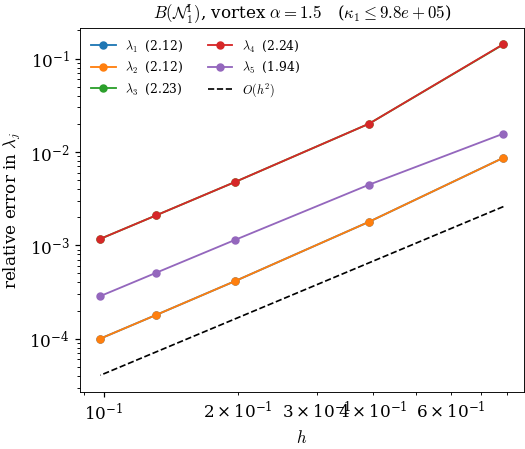

In [37]:
df = h_tables_lp["B(N1)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{I}}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b9_BN1.pdf")
plt.show()

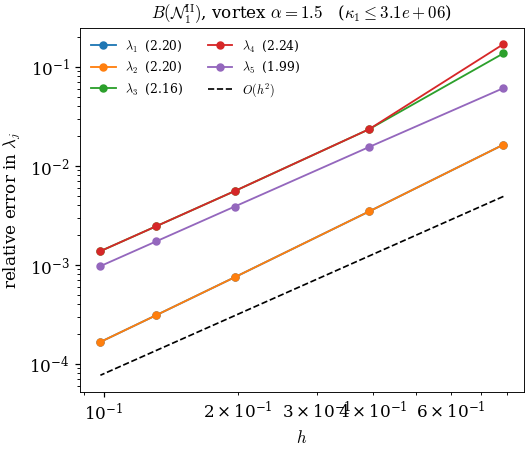

In [38]:
df = h_tables_lp["B(N2)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{II}}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b9_BN2.pdf")
plt.show()

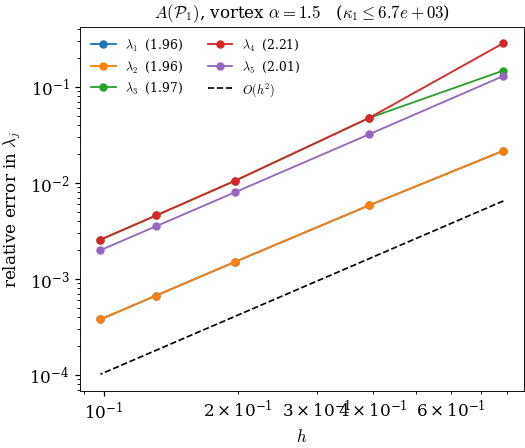

In [39]:
df = h_tables_lp["A(P)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_1$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_2$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_3$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_4$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_5$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_1)$, vortex $\alpha=1.5$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_h_b9_AP.pdf")
plt.show()

In [40]:
p_tables_lp = {f: p_study(f, "b9", alpha=ALPHA_MAIN) for f in FORMS}
for f in FORMS:
    display(show(p_tables_lp[f], default="{:.3e}",
                 rules=[("dof", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
                 caption=rf"$p$-refinement, **{f}**, vortex $\alpha = {ALPHA_MAIN}$, "
                         rf"$N = {N_PREF}$, $R_m = 1$"))

**$p$-refinement, **B(N1)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,545,1.787e-03,1.787e-03,2.007e-02,2.007e-02,4.460e-03,6.98e+03
2,1857,1.329e-05,1.329e-05,8.835e-05,8.835e-05,5.575e-05,1.27e+05
3,3937,1.367e-06,1.367e-06,8.810e-08,8.810e-08,6.859e-07,1.57e+06
4,6785,1.660e-07,1.660e-07,1.966e-08,1.966e-08,1.312e-08,6.88e+06


**$p$-refinement, **B(N2)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,1345,3.455e-03,3.455e-03,2.338e-02,2.338e-02,1.546e-02,1.74e+04
2,3169,1.499e-05,1.499e-05,9.729e-05,9.729e-05,8.248e-05,1.71e+05
3,5761,1.409e-06,1.409e-06,9.162e-08,9.162e-08,2.428e-07,1.49e+06
4,9121,1.821e-07,1.821e-07,1.212e-08,1.212e-08,1.393e-09,7.59e+06


**$p$-refinement, **A(P)**, vortex $\alpha = 1.5$, $N = 8$, $R_m = 1$**

,dof,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\lambda_{4}$,$\lambda_{5}$,$\kappa_1$
r,,,,,,,
1,146,5.846e-03,5.846e-03,4.762e-02,4.762e-02,3.215e-02,4.77e+02
2,546,5.554e-05,5.554e-05,2.140e-04,2.140e-04,1.807e-04,1.93e+03
3,1202,3.410e-06,3.410e-06,4.006e-07,4.006e-07,3.982e-07,6.94e+03
4,2114,6.119e-07,6.119e-07,1.255e-08,1.255e-08,2.794e-09,1.61e+04


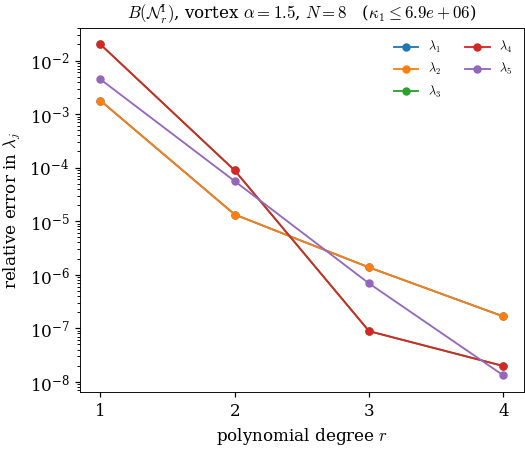

In [41]:
df = p_tables_lp["B(N1)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{I}}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b9_BN1.pdf")
plt.show()

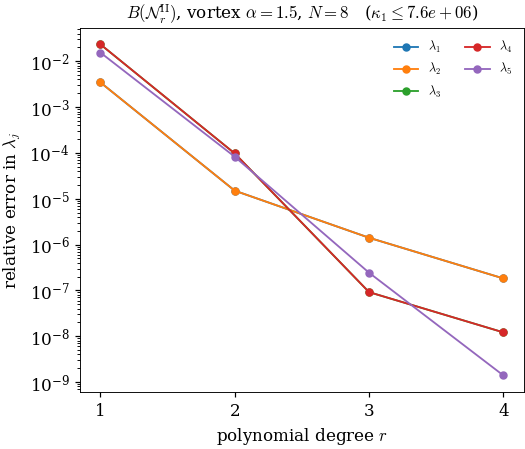

In [42]:
df = p_tables_lp["B(N2)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$B(\mathcal{N}^{\mathrm{II}}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b9_BN2.pdf")
plt.show()

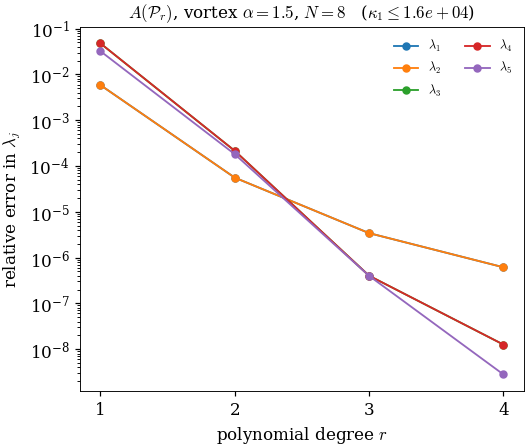

In [43]:
df = p_tables_lp["A(P)"]

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.semilogy(df.index, df[EIG_COLS[0]], "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2, label=r"$\lambda_1$")
ax.semilogy(df.index, df[EIG_COLS[1]], "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2, label=r"$\lambda_2$")
ax.semilogy(df.index, df[EIG_COLS[2]], "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2, label=r"$\lambda_3$")
ax.semilogy(df.index, df[EIG_COLS[3]], "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2, label=r"$\lambda_4$")
ax.semilogy(df.index, df[EIG_COLS[4]], "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2, label=r"$\lambda_5$")
ax.set_xlabel(r"polynomial degree $r$")
ax.set_xticks(list(P_LEVELS))
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"$A(\mathcal{P}_r)$, vortex $\alpha=1.5$, $N=8$"
             + rf"   ($\kappa_1 \leq {df[r'$\kappa_1$'].max():.1e}$)")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "breg1_p_b9_AP.pdf")
plt.show()

The $h$-rates hold at $O(h^2)$ for the vortex too, in all three formulations — the
singularity is a point, and a point has measure zero, so it does not by itself destroy the
approximation order of the eigenvalues.

$p$-refinement is a different story. The gain per degree is markedly smaller than for the
$L^\infty$ fields of Section 3.3, and it flattens earlier. That is the expected behaviour
for a solution whose regularity is capped by a point singularity in the coefficient:
raising $r$ enriches the space everywhere, but the error is controlled by a neighbourhood
of one point, and only $h$-refinement resolves it. **For $L^p$ data, refine $h$ before
raising $r$.**

### 4.3 Convergence as $R_m$ varies

In [44]:
RM_VALUES_LP = (1.0, 2.0, 5.0)
REFERENCE_RM_LP = {}
for Rm in RM_VALUES_LP:
    beta_a = FIELDS["b9"](mesh_ref_lp, alpha=ALPHA_MAIN)
    stack = np.array([solve_form(f, mesh_ref_lp, R_REF, beta=beta_a, Rm=Rm,
                                 nev=NEV_REF, n_eigs=5, field="b9").values[:5]
                      for f in FORMS])
    REFERENCE_RM_LP[Rm] = stack.mean(axis=0)

rows = []
for Rm in RM_VALUES_LP:
    ref = REFERENCE_RM_LP[Rm]
    for form in FORMS:
        errs, kap = [], []
        for N in RM_LEVELS:
            mesh = crisscross_mesh(N)
            res = solve_form(form, mesh, 1, beta=FIELDS["b9"](mesh, alpha=ALPHA_MAIN),
                             Rm=Rm, nev=25, field="b9")
            got = assign(ref, res.values)
            errs.append([abs(got[j] - ref[j]) / abs(ref[j]) for j in range(5)])
            kap.append(res.kappa1)
        errs = np.array(errs)
        h = np.pi / np.array(RM_LEVELS, dtype=float)
        per_mode = np.array([rates(h, errs[:, j])[-1] for j in range(5)])
        rows.append(dict(Rm=Rm, formulation=form,
                         **{r"rate $\lambda_1$": per_mode[0],
                            "mean rate": per_mode.mean(),
                            "min rate": per_mode.min(),
                            r"$\kappa_1$ (finest)": kap[-1]}))
show(pd.DataFrame(rows).set_index(["Rm", "formulation"]), default="{:.2f}",
     rules=[(r"$\kappa_1$ (finest)", "{:.2e}"), ("Rm", "{:.1f}")],
     caption=rf"Observed $h$-refinement orders as $R_m$ varies, vortex "
             rf"$\alpha = {ALPHA_MAIN}$, $r = 1$")

**Observed $h$-refinement orders as $R_m$ varies, vortex $\alpha = 1.5$, $r = 1$**

rate $\lambda_1$ mean rate min rate $\kappa_1$ (finest)
Rm  formulation                                                        
1.0 B(N1)                   2.01      2.01     2.00            2.26e+06
    B(N2)                   2.15      2.06     2.00            7.42e+06
    A(P)                    1.99      2.00     1.99            1.03e+04
2.0 B(N1)                   2.59      2.24     2.00            8.91e+05
    B(N2)                   2.23      2.09     2.00            2.26e+06
    A(P)                    2.01      2.00     2.00            1.24e+04
5.0 B(N1)                   2.00      2.01     2.00            5.03e+05
    B(N2)                   1.86      1.94     1.86            7.85e+05
    A(P)                    1.97      1.98     1.97            1.83e+04

The order survives here as well, but with visibly less margin than for the $L^\infty$
fields. The estimates are noisier — several entries overshoot $2$, reaching $2.59$ for
$B(\mathcal{N}^{\mathrm{I}}_1)$ at $R_m = 2$, which is a pre-asymptotic artefact of taking a
rate from four levels rather than a real superconvergence — and the minimum over the five
modes falls to $1.86$ at $R_m = 5$, where the effective magnitude of the field near the
singularity and the weakened diffusion compound each other. This is the first place in the
study where the rate itself, rather than only the constant, starts to move.

### 4.4 Pseudospectra across formulations and $R_m$

In [45]:
PS_WINDOW_LP = ((0.0, 12.0), (-6.0, 6.0))
ps_lp = {(f, Rm): run_ps(f, "b9", Rm=Rm, alpha=ALPHA_MAIN, window=PS_WINDOW_LP)
         for Rm in (1.0, 5.0) for f in FORMS}
show(ps.diagnostics_frame(ps_lp.values(), keys=("form", "Rm")), default="{:.3e}",
     rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
            ("Rm", "{:.1f}")],
     caption=rf"Projection diagnostics, vortex $\alpha = {ALPHA_MAIN}$")

**Projection diagnostics, vortex $\alpha = 1.5$**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,Rm,,,,,,,
B(N1),1.0,3281,103,8.722e-13,1,6,1.546e-13,12
B(N2),1.0,8161,103,1.951e-12,1,7,1.781e-13,12
A(P),1.0,842,103,1.622e-14,1,7,7.629e-14,12
B(N1),5.0,3281,104,4.403e-13,5,7,9.948e-14,50
B(N2),5.0,8161,104,3.246e-13,5,8,1.167e-12,50
A(P),5.0,842,105,3.501e-15,5,8,8.925e-14,49


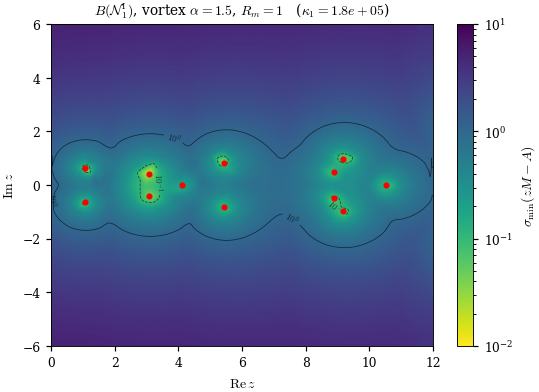

In [46]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("B(N1)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{I}}_1)$, vortex $\alpha=1.5$, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_BN1_Rm1.pdf")
    plt.show()

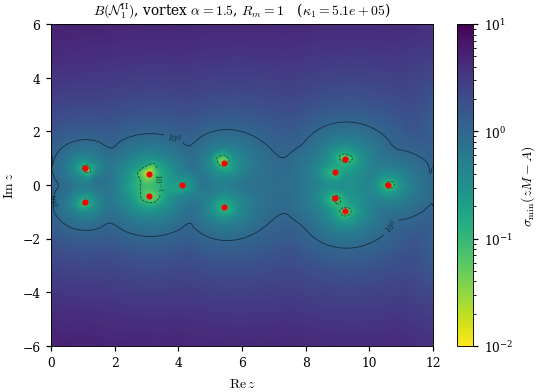

In [47]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("B(N2)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{II}}_1)$, vortex $\alpha=1.5$, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_BN2_Rm1.pdf")
    plt.show()

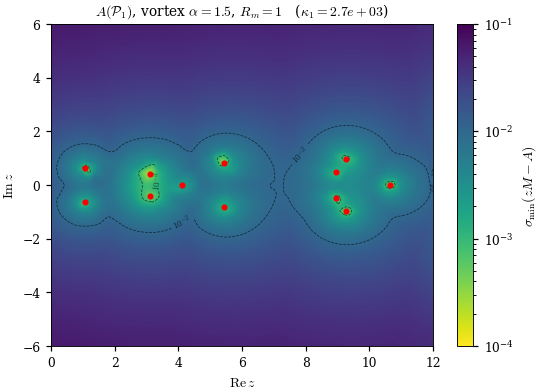

In [48]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("A(P)", 1.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$A(\mathcal{P}_1)$, vortex $\alpha=1.5$, $R_m=1$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_AP_Rm1.pdf")
    plt.show()

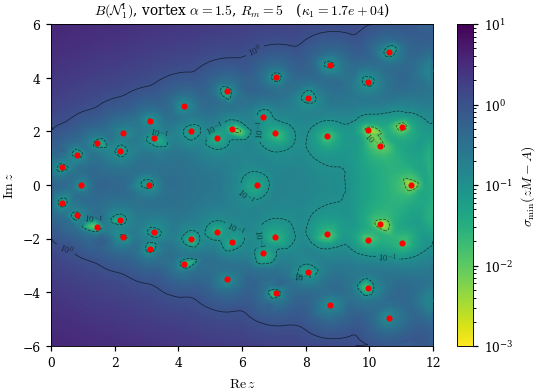

In [49]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("B(N1)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{I}}_1)$, vortex $\alpha=1.5$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_BN1_Rm5.pdf")
    plt.show()

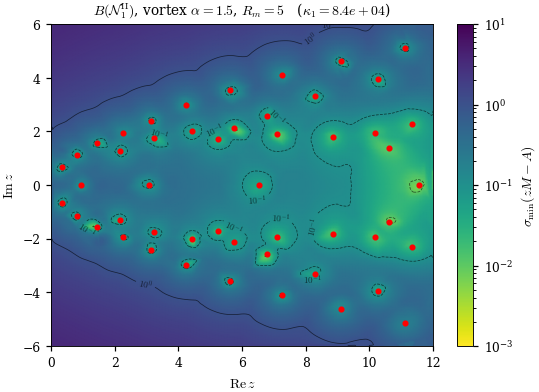

In [50]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("B(N2)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$B(\mathcal{N}^{\mathrm{II}}_1)$, vortex $\alpha=1.5$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_BN2_Rm5.pdf")
    plt.show()

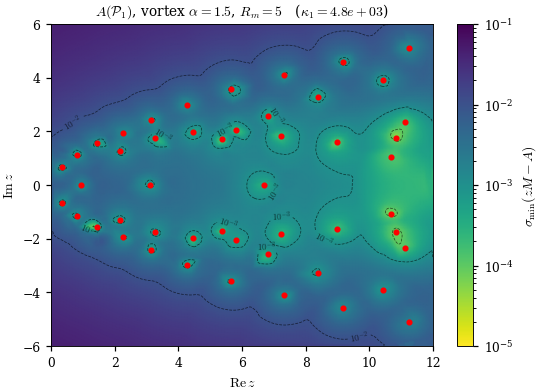

In [51]:
with matplotlib.rc_context(PS_RC):
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    r_ = ps_lp[("A(P)", 5.0)]
    ps.plot_pseudospectrum(r_, ax=ax,
                           title=r"$A(\mathcal{P}_1)$, vortex $\alpha=1.5$, $R_m=5$"
                                 + rf"   ($\kappa_1 = {r_['kappa1']:.1e}$)")
    fig.savefig(FIGDIR / "breg1_ps_b9_AP_Rm5.pdf")
    plt.show()

### 4.5 Non-normality against the strength of the singularity

A scalar summary makes the comparison across formulations and exponents readable. For a
fixed $\varepsilon$, the quantity

$$
\text{bulge}(\varepsilon) \;=\; \max\{\,\operatorname{dist}(z, \Lambda_h)\ :\ \sigma_{\min}(zM-A) \le \varepsilon\,\} \;-\; \varepsilon
$$

is zero for a normal operator and grows with non-normality. Because the absolute level of
$\sigma_{\min}$ is not comparable between formulations, $\varepsilon$ is set per pencil as
the second percentile of its own sampled values, and is reported alongside.

In [52]:
RM_HIGH = 5.0
rows = []
for a in ALPHAS:
    for form in FORMS:
        r_ = run_ps(form, "b9", Rm=RM_HIGH, alpha=a, window=PS_WINDOW_LP)
        b, lvl = bulge(r_)
        rows.append(dict(alpha=a, formulation=form,
                         **{r"$\varepsilon$ (2nd pctile)": lvl, "bulge": b,
                            r"max $|\mathrm{Im}\,\lambda|$":
                                float(np.abs(r_["ritz_in"].imag).max())
                                if r_["ritz_in"].size else np.nan,
                            r"$\kappa_1$": r_["kappa1"]}))
show(pd.DataFrame(rows).set_index(["alpha", "formulation"]), default="{:.3e}",
     rules=[("bulge", "{:.3f}"), ("alpha", "{:.2f}"),
            (r"max $|\mathrm{Im}\,\lambda|$", "{:.3f}")],
     caption=rf"Non-normality against the strength of the singularity, at fixed "
             rf"$R_m = {RM_HIGH:g}$, $N = {PS_N}$, $r = {PS_R}$")

**Non-normality against the strength of the singularity, at fixed $R_m = 5$, $N = 20$, $r = 1$**

$\varepsilon$ (2nd pctile)  bulge  \
alpha formulation                                     
1.00  B(N1)                        3.963e-02  0.202   
      B(N2)                        4.450e-02  0.327   
      A(P)                         5.324e-04  0.595   
1.25  B(N1)                        3.243e-02  0.360   
      B(N2)                        3.671e-02  0.485   
      A(P)                         3.726e-04  0.622   
1.50  B(N1)                        2.551e-02  0.656   
      B(N2)                        2.242e-02  0.704   
      A(P)                         2.173e-04  0.573   
1.75  B(N1)                        1.078e-02  0.658   
      B(N2)                        1.417e-02  0.638   
      A(P)                         1.853e-04  0.550   

                  max $|\mathrm{Im}\,\lambda|$ $\kappa_1$  
alpha formulation                                          
1.00  B(N1)                              5.540  1.524e+04  
      B(N2)                              5.725  2.902e+04  
      A(P)                               5.699  4.516e+03  
1.25  B(N1)                              5.199  1.589e+04  
      B(N2)                              5.380  3.061e+04  
      A(P)                               5.355  4.643e+03  
1.50  B(N1)                              4.950  1.706e+04  
      B(N2)                              5.124  8.363e+04  
      A(P)                               5.107  4.768e+03  
1.75  B(N1)                              4.796  9.449e+04  
      B(N2)                              4.969  1.380e+05  
      A(P)                               4.966  4.882e+03

Here, unlike the $L^\infty$ family, the measure does move. For the two $B$ formulations the
bulge roughly triples across the range, from $0.20$ to $0.66$ and from $0.33$ to $0.64$, so
the resolvent landscape is genuinely more distorted as the singularity strengthens.
$A(\mathcal{P}_1)$ sits flat near $0.55$–$0.62$ throughout, but at an $\varepsilon$ two
decades lower than the $B$ rows, so its column should be read against itself and not
against theirs.

The growth is not an artefact of the spectrum spreading out: $\max|\operatorname{Im}\lambda|$
*decreases* slightly over the same range, from about $5.5$ to $4.8$. The eigenvalues are
contracting towards the real axis while the $\varepsilon$-contours around them bulge further
— which is the definition of increasing non-normality, and is what the loss of $L^\infty$
control on $\beta$ costs.

Conditioning is flat in $\alpha$ throughout, so once again what degrades is the
approximation theory responding to the data, not the linear algebra.

<a id="5"></a>
## 5. Summary

**What survives the loss of regularity.**

1. **Optimal $h$-convergence.** Every field tested here, from the discontinuous shears down
   to the $L^p$ vortex, gives $O(h^{2r})$ on the first five eigenvalues in all three
   formulations. Rates are the last thing to go.
2. **Cross-formulation agreement, but by a shrinking margin.** Seven to eleven digits for
   the $L^\infty$ fields; four to six for the vortex, falling monotonically as $\alpha$
   rises. The margin is a usable proxy for regularity even where the theory gives no
   estimate.
3. **No detectable pollution.** The wide-window scans of Section 3.5 find the same
   eigenvalues and the same wells in all three formulations, at both Reynolds numbers
   tested. Nothing here misbehaves the way the deliberately-broken element of the top-form
   study does.

**What degrades, and in what order.**

1. **$p$-refinement first.** Exponential convergence is lost as soon as $\beta$ leaves
   $W^{1,\infty}$, and is weakest of all for the point singularity of $\beta_9$. For rough
   data, refine $h$ before raising $r$.
2. **Agreement between formulations next**, monotonically with $\alpha$.
3. **The rate itself last**, and only in the corner where a strong singularity meets a high
   Reynolds number (Section 4.3).

**What is *not* the cause.** The conditioning of $A - \tau M$ is reported with every table
and every figure in this notebook, and it is flat in $\alpha$ and mildly growing in $R_m$
and $h^{-1}$. Nothing that degrades above is the linear algebra failing; it is the
approximation theory responding to the data, which is what the study set out to measure.

**Caveats.** Nothing is stabilised, deliberately: SUPG and its relatives perturb the
operator whose spectrum is the object of study. For the bounded fields that means
respecting $h\|\beta\|_\infty R_m/2 \lesssim 1$, which every table above does. For the
vortex there is no mesh-independent $\|\beta\|_\infty$ at all, so the effective magnitude
is reported in Section 4.1 instead and the Reynolds numbers are kept correspondingly
modest.

In [53]:
klog = pd.DataFrame(KAPPA_LOG)
worst = klog.loc[klog[r"Hager $\kappa_1$"].idxmax()]
print(f"{len(klog)} eigensolves, each with kappa(A - tau M) estimated.\n")
print(f"  worst normwise kappa_1 : {worst[r'Hager $\kappa_1$']:.3e}"
      f"   ({worst.get('form', '?')}, field {worst.get('field', '?')}, "
      f"r={worst.get('r', 0):.0f}, Rm={worst.get('Rm', 1):g}, n={worst['n']:.0f})")
print(f"  median normwise kappa_1: {klog[r'Hager $\kappa_1$'].median():.3e}")
print(f"  worst MUMPS COND1      : {klog['MUMPS COND1'].max():.3e}")
print(f"  MUMPS INFOG(1) != 0    : {int((klog['INFOG(1)'] != 0).sum())} of {len(klog)}")
print(f"\nfigures written to {FIGDIR.resolve()}")
for q in sorted(FIGDIR.glob("breg1_*.pdf")):
    print("  ", q.name)

210 eigensolves, each with kappa(A - tau M) estimated.

  worst normwise kappa_1 : 1.241e+08   (B(N1), field b7, r=3, Rm=1, n=34849)
  median normwise kappa_1: 3.477e+05
  worst MUMPS COND1      : 3.642e+05
  MUMPS INFOG(1) != 0    : 0 of 210

figures written to /Users/lourenco/Desktop/Dissertation_Firedrake/Experiments/final/figures
   breg1_field_b6.pdf
   breg1_field_b7.pdf
   breg1_field_b8.pdf
   breg1_field_b9.pdf
   breg1_h_b7_AP.pdf
   breg1_h_b7_BN1.pdf
   breg1_h_b7_BN2.pdf
   breg1_h_b9_AP.pdf
   breg1_h_b9_BN1.pdf
   breg1_h_b9_BN2.pdf
   breg1_p_b7_AP.pdf
   breg1_p_b7_BN1.pdf
   breg1_p_b7_BN2.pdf
   breg1_p_b9_AP.pdf
   breg1_p_b9_BN1.pdf
   breg1_p_b9_BN2.pdf
   breg1_ps_b8_AP_Rm1.pdf
   breg1_ps_b8_AP_Rm5.pdf
   breg1_ps_b8_BN1_Rm1.pdf
   breg1_ps_b8_BN1_Rm5.pdf
   breg1_ps_b8_BN2_Rm1.pdf
   breg1_ps_b8_BN2_Rm5.pdf
   breg1_ps_b9_AP_Rm1.pdf
   breg1_ps_b9_AP_Rm5.pdf
   breg1_ps_b9_BN1_Rm1.pdf
   breg1_ps_b9_BN1_Rm5.pdf
   breg1_ps_b9_BN2_Rm1.pdf
   breg1_ps_b9_BN2_Rm5.